# ISIS `photomet` (Hapke) hillshading vs. the plain Lambertian fallback

`image_generation.ipynb`'s hillshade-based ortho basemap (`dem_ortho_result.ortho`, Phase 3) is
shaded with a Hapke bidirectional reflectance function by default (ISIS `photomet`,
`PHTNAME=HAPKEHEN`, `hapke.hapke_shade_ortho`). `dem_ortho.fetch_dem_and_ortho`/
`despeckle_and_shade_ortho`'s `hapke` parameter (`hapke.DEFAULT_HAPKE_SHADING`) still keeps the
original plain Lambertian `matplotlib.colors.LightSource.hillshade` blend (`hapke.shade_ortho`)
available as a fallback (`hapke=False`) -- sun-direction-lit, but not a physically-based
photometric model (no opposition surge, no macroscopic-roughness term, no lunar-specific
reflectance behavior). This notebook is a reference/regression comparison between the two --
showing what the Hapke default changes relative to that fallback for one candidate image.

The tricky part evaluated here: `photomet`'s automatic angle sources (`ANGLESOURCE=ELLIPSOID`/
`DEM`) need a real ISIS camera model embedded in the cube (via `spiceinit`) to derive
incidence/emission/phase angles from -- but this ortho is a flat, map-projected mosaic with no
ISIS camera model at all (real or synthetic). The fix used here: `ANGLESOURCE=BACKPLANE`, feeding
`photomet` angle rasters computed directly in Python (`hapke._terrain_photometric_angles`) --
`photomet` only does the Hapke math, not the geometry. This sidesteps the "no camera model"
problem entirely.

Those angle rasters use the synthetic camera's own **finite position**
(`Camera.camera_center_moon_me_m`, used directly in MOON_ME coordinates -- see
`hapke._terrain_photometric_angles`'s own docstring), not an idealized infinitely-distant nadir
viewer -- so emission and phase vary per pixel from parallax (each pixel's own vector to the
spacecraft), the same perspective geometry `sat_sim`'s own synthetic render is posed with, not
just local terrain slope.

Minimum setup to get there: reuses `image_generation.ipynb`'s Phase 1-2 exactly (same manifest,
same `TrnTestDataSet`), but skips `dataset.populate()` entirely -- `entry.camera` is enough to
fetch a DEM/ortho pair, and this notebook doesn't need the `sat_sim` render or the ISIS WAC crop
either phase would otherwise generate. Displays the existing Lambertian ortho blinked against a
freshly-fetched Hapke-shaded ortho of the same footprint, via the same `plot_overlay_toggle`
blink-comparator Phase 5B/6B use -- here comparing the two shading modes directly against each
other (both share the exact same pixel grid, being the same DEM/ortho fetch with only the final
shading step differing) rather than comparing a render against a basemap.

In [1]:
import trntest
from trntest import dem_ortho, plotting

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
camera = entry.camera

print(f"EDR product: {entry.edr_product}")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

EDR product: M1327210646CE
Ground footprint center (lon, lat): (np.float64(169.57486295444002), np.float64(38.762076138016))


## Fetch both shading variants

`entry.dem_ortho_result` is the current *default* basemap -- Hapke-shaded (resumed from disk if
`image_generation.ipynb` already generated it for this manifest entry, else fetched fresh here;
see `TrnTestEntry.dem_ortho_result`'s own docstring for how it stays mode-aware about which
cached file to resume from). `dem_ortho.fetch_dem_and_ortho(..., hapke=False)` fetches the same
DEM/ortho pair again -- cheap, Lunaserv/Astropedia fetches are independently cached by `cache.py`
-- but shades it with the plain Lambertian fallback instead, writing to its own `ortho_shaded.tif`
so it doesn't collide with the Hapke file. Passes `extra_footprint_lonlat_deg=entry.crop_footprint`
explicitly, matching `entry.dem_ortho_result`'s own internal call -- without it, this second call's
smaller camera-only-footprint AOI would silently overwrite the *shared* per-candidate
`dem_filled-tile-0.tif` with a differently-sized DEM, corrupting `entry.dem_ortho_result`'s
already-fetched (larger, crop-unioned) ortho pairing for any later resumer.

In [2]:
dem_ortho_hapke = entry.dem_ortho_result
dem_ortho_lambertian = dem_ortho.fetch_dem_and_ortho(
    camera, entry.per_image_config, extra_footprint_lonlat_deg=entry.crop_footprint, hapke=False
)

print("Hapke ortho:      ", dem_ortho_hapke.ortho)
print("Lambertian ortho: ", dem_ortho_lambertian.ortho)

ROI center (lon,lat deg): (np.float64(169.57486295444002), np.float64(38.762076138016)), bbox (local m): (-119396.13176061198, -120199.55455817058, 119335.20445016897, 123845.30553985553)
ROI size 2387x2440 px (~100.0 m/px)


WAC_EMP tile: WAC_EMP_643NM_E300N1350_304P


Hapke ortho:       /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc_realparams_normaltilt_wacemp.tif
Lambertian ortho:  /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_wacemp.tif


## Blink comparison

Both orthos share the exact same georeferencing/pixel grid (same camera footprint, same DEM, only
the final shading step differs), so `plotting.plot_render_toggle` applies directly -- the same
blink comparator `image_generation.ipynb`'s Phase 8 uses for `hillshade` vs. `reproject` (no
rotation needed here, since these orthos are already north-up map-projected, unlike a raw
sensor-frame render). Its title names each frame directly (`"☑ Lambertian... / ☐ ISIS photomet..."`,
flipped on the other frame) rather than a generic "Overlay Visibility" toggle, which doesn't say
which of two equally-weighted images -- not a base and an overlay -- is showing.

What to look for: emission-angle-dependent brightening toward the side of the frame the camera is
looking more obliquely at (a parallax effect the Lambertian path has no equivalent of, since it
only considers the Sun, never the viewer), opposition-surge brightening near the sub-solar point,
a different incidence-angle falloff, etc.


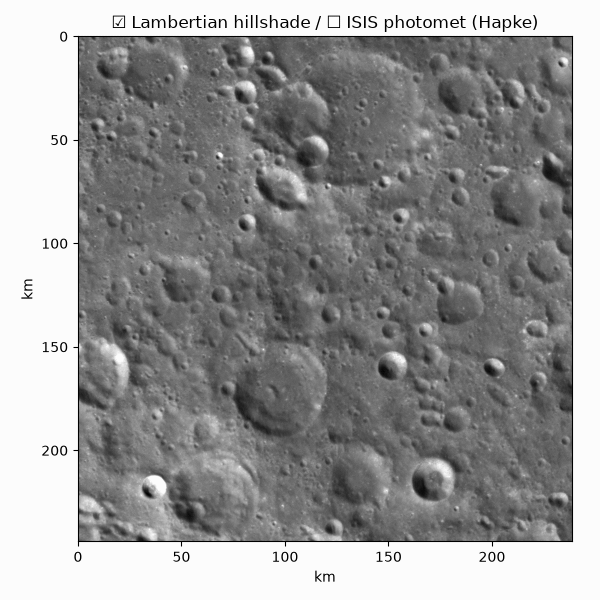

In [3]:
width_km = (dem_ortho_hapke.bbox[2] - dem_ortho_hapke.bbox[0]) / 1000.0
height_km = (dem_ortho_hapke.bbox[3] - dem_ortho_hapke.bbox[1]) / 1000.0
plotting.plot_render_toggle(
    dem_ortho_lambertian.ortho,
    dem_ortho_hapke.ortho,
    0,
    width_km,
    height_km,
    "Lambertian hillshade",
    "ISIS photomet (Hapke)",
)